In [2]:
import sys
sys.path.append("..")

from src.data_loader import load_raw_data

## Data Loading

1. Load data and reveal the first few columns.

In [3]:
df = load_raw_data()
df.head()

Loaded data via local (30000 rows, 25 columns).


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


## Data Audit

2. Shape of data - how many rows and columns.

In [4]:
print(df.shape)


(30000, 25)


3. Dtypes - what does pandas think each column is?

In [5]:
print(df.dtypes.value_counts())
df.dtypes

float64    13
int64      12
Name: count, dtype: int64


ID                              int64
LIMIT_BAL                     float64
SEX                             int64
EDUCATION                       int64
MARRIAGE                        int64
AGE                             int64
PAY_0                           int64
PAY_2                           int64
PAY_3                           int64
PAY_4                           int64
PAY_5                           int64
PAY_6                           int64
BILL_AMT1                     float64
BILL_AMT2                     float64
BILL_AMT3                     float64
BILL_AMT4                     float64
BILL_AMT5                     float64
BILL_AMT6                     float64
PAY_AMT1                      float64
PAY_AMT2                      float64
PAY_AMT3                      float64
PAY_AMT4                      float64
PAY_AMT5                      float64
PAY_AMT6                      float64
default.payment.next.month      int64
dtype: object

4. Nulls 

In [6]:
print(df.isnull().sum().sum())

0


5. For every column that's supposed to represent a fixed set of categories (even if its stored as an integer, like EDUCATION) - check `value_counts()` and compare against expected valid values, according to the codebook/documentation

In [7]:
print(df["EDUCATION"].value_counts())
print(df["MARRIAGE"].value_counts())

EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64
MARRIAGE
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64


6. For every numeric column check `describe()` for obviously impossible values (negative ages, ages of 200, negative bill amounts that shouldn't be negative etc)

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


In [9]:
df["EDUCATION"]

0        2
1        2
2        2
3        2
4        2
        ..
29995    3
29996    3
29997    2
29998    3
29999    2
Name: EDUCATION, Length: 30000, dtype: int64

7. Check duplicates and values of specific columns

In [10]:
print(df.duplicated().sum())

for col in ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']:
    print(df[col].value_counts().sort_index())
    print()

0
PAY_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64

PAY_2
-2     3782
-1     6050
 0    15730
 1       28
 2     3927
 3      326
 4       99
 5       25
 6       12
 7       20
 8        1
Name: count, dtype: int64

PAY_3
-2     4085
-1     5938
 0    15764
 1        4
 2     3819
 3      240
 4       76
 5       21
 6       23
 7       27
 8        3
Name: count, dtype: int64

PAY_4
-2     4348
-1     5687
 0    16455
 1        2
 2     3159
 3      180
 4       69
 5       35
 6        5
 7       58
 8        2
Name: count, dtype: int64

PAY_5
-2     4546
-1     5539
 0    16947
 2     2626
 3      178
 4       84
 5       17
 6        4
 7       58
 8        1
Name: count, dtype: int64

PAY_6
-2     4895
-1     5740
 0    16286
 2     2766
 3      184
 4       49
 5       13
 6       19
 7       46
 8        2
Name: count, dtype: int64



The official dataset documentation defines PAY_* as: -1 = pay duly, 1 = payment delay 1 month, 2 = delay 2 months, ... 8 = delay 8 months and above. The documentation never defines what 0 or -2 mean.

The widely-accepted interpretation among people who've worked with this exact dataset (including discussion around the original paper) is:

- -1 = paid duly (on time)
- 0 = likely means "paid, but with revolving/minimum-only balance" or simply "no delay recorded" — not officially documented, but far too common and evenly distributed to be an error
- -2 = likely "no consumption / no bill that month" (i.e., the account had no transaction to be late or on time about)
- 1–8 = documented, delay in months

## EDA

1. Target Imbalance 

In [11]:
import matplotlib.pyplot as plt

target_counts = df['default.payment.next.month'].value_counts()
target_pct = df['default.payment.next.month'].value_counts(normalize=True)*100

print("Target variable counts:", target_counts)
print("Pct of target variable:", target_pct)


Target variable counts: default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64
Pct of target variable: default.payment.next.month
0    77.88
1    22.12
Name: proportion, dtype: float64


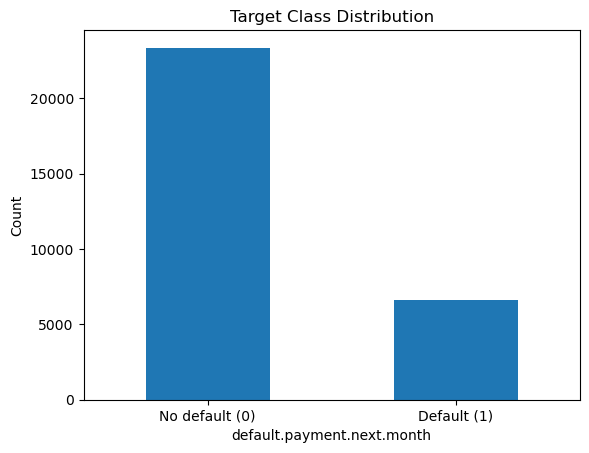

In [12]:
target_counts.plot(kind='bar')
plt.xticks([0,1], ['No default (0)', 'Default (1)'], rotation=0)
plt.ylabel('Count')
plt.title('Target Class Distribution')
plt.show()

The taget variable `default.payment.next.month` is imbalanced: 23,364 clients (77.88%) did not default while 6,636 clients(22.12%) did - roughly a 3.5:1 ratio of non-default to default.

This has direct implications for the rest if the project:

1. Accurracy is not reliable metric . A model that predicts "no default" for every client would score ~77.88% accuracy while being completely useless - it would never catch a single actual defaulter. This is why precision, recall, F1 and ROC-AUC are the metrics that matter here: they specifically capture how well the model identifies the minority (default) class, rather than reqarding it for defaulting to minority.

2. Class imbalance needs to be addressed during modeling, not just measured here. Options to consider later include class weighting (penalizing misclassification of minority class more heavily) or resampling techniques (e.g SMOTE). The decision on which approach to use will be made in the modeling phase, but the imbalance identified here is why that decision is necessary.

The 77.88% acts as a reference point; its the score a base/naive/trivia classifier would get, and any real model built needs to be evaluated against more than that number alone to be meaningful.

2. Numeric Feature Distributions


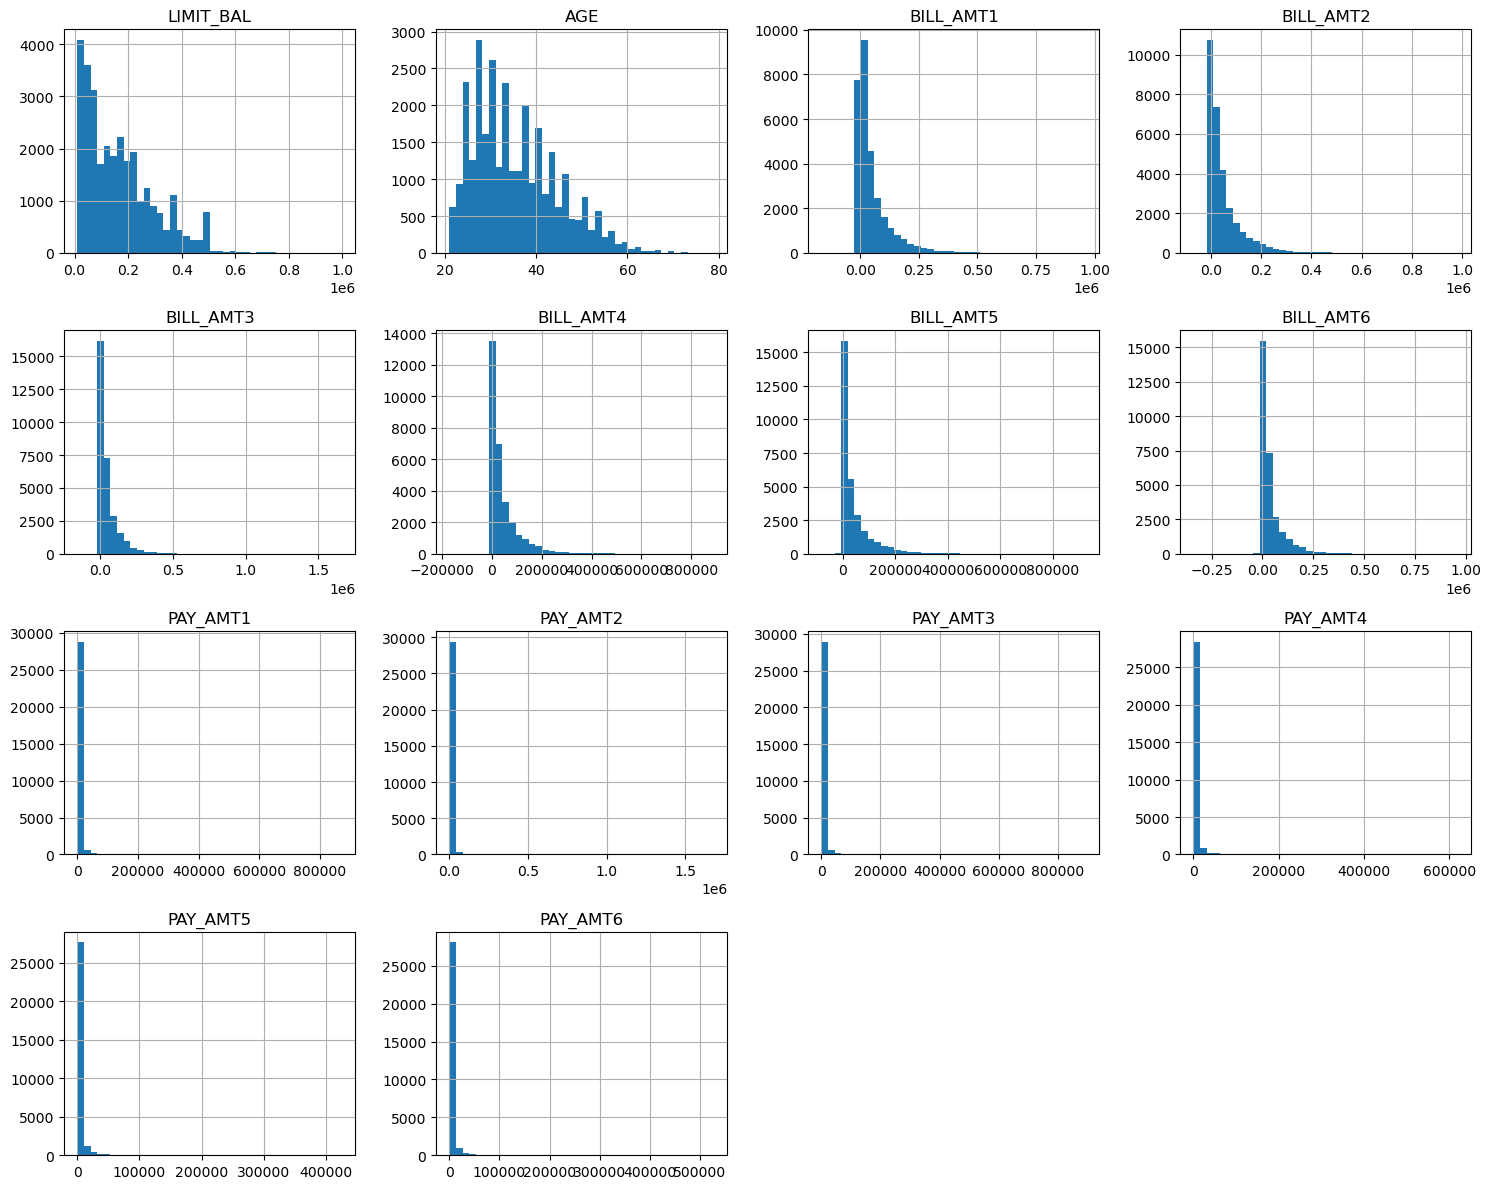

In [13]:
num_cols = ['LIMIT_BAL', 'AGE'] + [f'BILL_AMT{i}' for i in range(1,7)] + [f'PAY_AMT{i}' for i in range(1,7)]

df[num_cols].hist(figsize=(15,12), bins=40)
plt.tight_layout()
plt.show()

`LIMIT_BAL`, `BILL_AMT*` and `PAY_AMT*` columns are right skewed, with most clients clustered at lower values and along tail of extreme high values - consistent with how income, spending and credit limits are typically distributed in real populations.

This skew is a candidate for loh-transformation during preprocessing, since models like logistic regression and neural networks can be disproportionately influenced by extreme values when features aren't on comparable scales.

#### Feature vs Target Relationship

This determines whether a feature actually differ between clients who defaulted and clients who didn't. A feature that looks identical across both classes probably won't help the model much; one that clearly separates the classes is a strong candidate preditor.

##### 1. Categorical features vs. Target - default rate by group

For `SEX`, `EDUCATION`, `MARRIAGE` and `PAY_*`  columns, the right comparison is default rate within each category not raw counts (raw counts are misleading if group sizes differ a lot).

In [14]:
for col in ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0']:
    print(df.groupby(col)['default.payment.next.month'].mean().sort_index())
    print()

SEX
1    0.241672
2    0.207763
Name: default.payment.next.month, dtype: float64

EDUCATION
0    0.000000
1    0.192348
2    0.237349
3    0.251576
4    0.056911
5    0.064286
6    0.156863
Name: default.payment.next.month, dtype: float64

MARRIAGE
0    0.092593
1    0.234717
2    0.209283
3    0.260062
Name: default.payment.next.month, dtype: float64

PAY_0
-2    0.132294
-1    0.167781
 0    0.128113
 1    0.339479
 2    0.691414
 3    0.757764
 4    0.684211
 5    0.500000
 6    0.545455
 7    0.777778
 8    0.578947
Name: default.payment.next.month, dtype: float64



##### 2. Numeric features vs target - compare distribution across clases

For continous features like `LIMIT_BAL` and `AGE`, boxplots split by target class show whether the distribution shifts meaningfully between defaulters and non-defaulters.

<Axes: xlabel='default.payment.next.month', ylabel='AGE'>

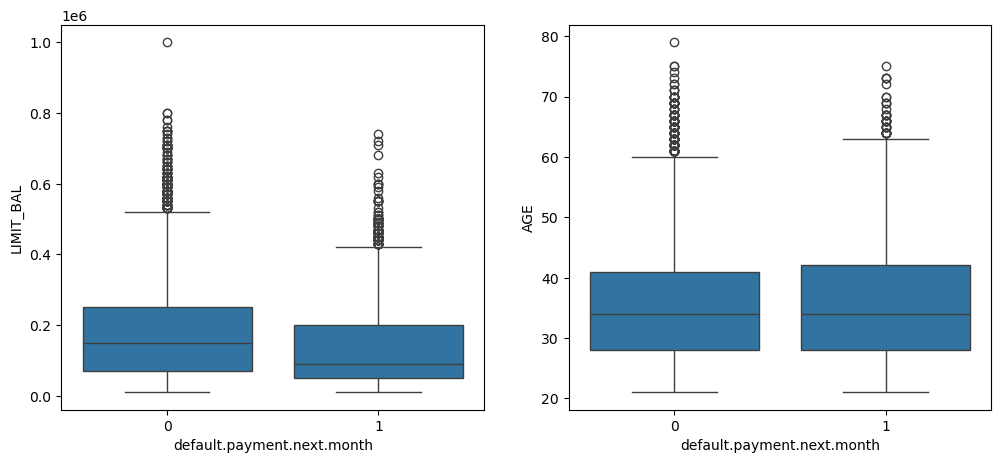

In [16]:
import seaborn as sns 

fig, axes = plt.subplots(1,2, figsize=(12,5))
sns.boxplot(data=df, x='default.payment.next.month', y='LIMIT_BAL', ax=axes[0])
sns.boxplot(data=df, x='default.payment.next.month', y='AGE', ax=axes[1])

Lower credit limits correlate with higher default rates, nost likely since limits are often set based in assessed risk in the first place.

Clients who default tend to have lower `LIMIT_BAL`(consistent with limits being risk-adjusted at issuance) and slightly younger median `AGE`, though the `AGE` difference is much less pronounced than the `LIMIT_BAL` difference.

##### 3. Correlation matrix - how features relate to each other and to the target 

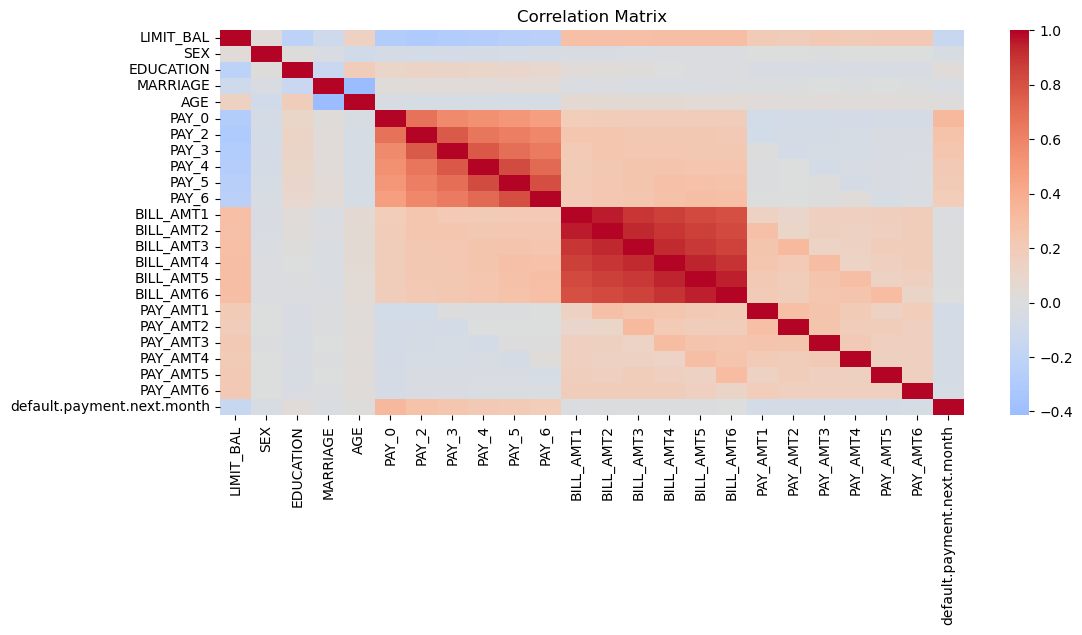

default.payment.next.month    1.000000
PAY_0                         0.324794
PAY_2                         0.263551
PAY_3                         0.235253
PAY_4                         0.216614
PAY_5                         0.204149
PAY_6                         0.186866
EDUCATION                     0.028006
AGE                           0.013890
BILL_AMT6                    -0.005372
BILL_AMT5                    -0.006760
BILL_AMT4                    -0.010156
BILL_AMT3                    -0.014076
BILL_AMT2                    -0.014193
BILL_AMT1                    -0.019644
MARRIAGE                     -0.024339
SEX                          -0.039961
PAY_AMT6                     -0.053183
PAY_AMT5                     -0.055124
PAY_AMT3                     -0.056250
PAY_AMT4                     -0.056827
PAY_AMT2                     -0.058579
PAY_AMT1                     -0.072929
LIMIT_BAL                    -0.153520
Name: default.payment.next.month, dtype: float64

In [18]:
plt.figure(figsize=(12,5))
sns.heatmap(df.drop(columns=['ID']).corr(), cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Matrix')
plt.show()

# correlation with target specifically, sorted
df.drop(columns=['ID']).corr()['default.payment.next.month'].sort_values(ascending=False)

The `PAY_*` columns (recent payment status) shows by far the strongest correlation with the target, with `PAY_0`(most recent month) the highest at 0.32 - confirming that repayment behaviour is the most predictive strength decays for repayment status further back in time (`PAY_0` > `PAY_2` > `PAY_3`...). In contrast, `BILL_AMT*` columns are essentially uncorrelated with the target (~0), while `LIMIT_BAL` shows a moderate negative correlation(-0.15), reinforcing the boxplot finding that lower credit limits are associated with higher deafult risk.

### Preprocessing

1. Apply the `EDUCATION`/`MARRIAGE` cleanup we had decided on earlier on - fold undocumented codes into "others"
2. Drop `ID` - since its not a feature, just a row identifier. Leaving it in would let the model "memorize" by ID rather than learn generalizable patterns (unlikely to matter much here since)
3. Log-transform skewed numeric features(`LIMIT_BA`, `BILL_AMT*`, `PAY_AMT*`) - compresses the long right tail, making the distribution more symmetric. This matters because models like logistic regression and neural networks (which rely on gradient-based optimization and weighted sums of features) perform better and train more stably when features aren't dominated by a few extreme outlier values. Tree-based models like Random Forrest are immune to this - they split on thresholds, not magnitudes - so this step matters more for the baseline-if-logistic-regression and the neural net than it would for a tree-based baseline.
4. Train/validation/test split - stratified. Because of the imbalance(78/22), a random split could by chance produce a test set with a different imbalance ratio than train, skewing evaluation. Stratified splitting forces each split to preserve that same ~78/22 ratio.
5. Feature scaling (standardization) - required for the neural network (gradient descent converges better when features are on comparable scales) and for logistic regression (regularization penalizes coefficients unevenly if features aren't scaled). Tree-based models don't need this, so if the baseline is Random Forest, this step is NN/LogReg-specific.
6. Decide how to handle class imbalance in training - this is a modelling-adjacent decision but usually implemented at the preprocessing/training setup stage: class weights (`class_weight='balanced'` in sklearn,  or a custom weighted loss in TensorFlow) vs. resampling(SMOTE, undersampling). We pick one & justify.